# **Phase 1 - Data loading & EDA**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

path = "Reviews.csv"

df = pd.read_csv(path, encoding='latin1')
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid", palette="muted")

print("✅ Thư viện đã sẵn sàng!")

✅ Thư viện đã sẵn sàng!


In [4]:
print("=" * 55)
print("THÔNG TIN TỔNG QUAN DATASET")
print("=" * 55)
print(f"Số dòng      : {df.shape[0]:,}")
print(f"Số cột       : {df.shape[1]}")
print(f"\nCác cột      : {list(df.columns)}")
print(f"\nKiểu dữ liệu:")
print(df.dtypes)
print(f"\nGiá trị NULL:")
print(df.isnull().sum())

THÔNG TIN TỔNG QUAN DATASET
Số dòng      : 568,454
Số cột       : 10

Các cột      : ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Kiểu dữ liệu:
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

Giá trị NULL:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


In [5]:
print("\n📊 Phân phối điểm đánh giá (Score 1–5):")
print(df['Score'].value_counts().sort_index())
print(f"\nTrung bình : {df['Score'].mean():.2f}")
print(f"Trung vị   : {df['Score'].median():.1f}")
print(f"Std        : {df['Score'].std():.2f}")


📊 Phân phối điểm đánh giá (Score 1–5):
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

Trung bình : 4.18
Trung vị   : 5.0
Std        : 1.31


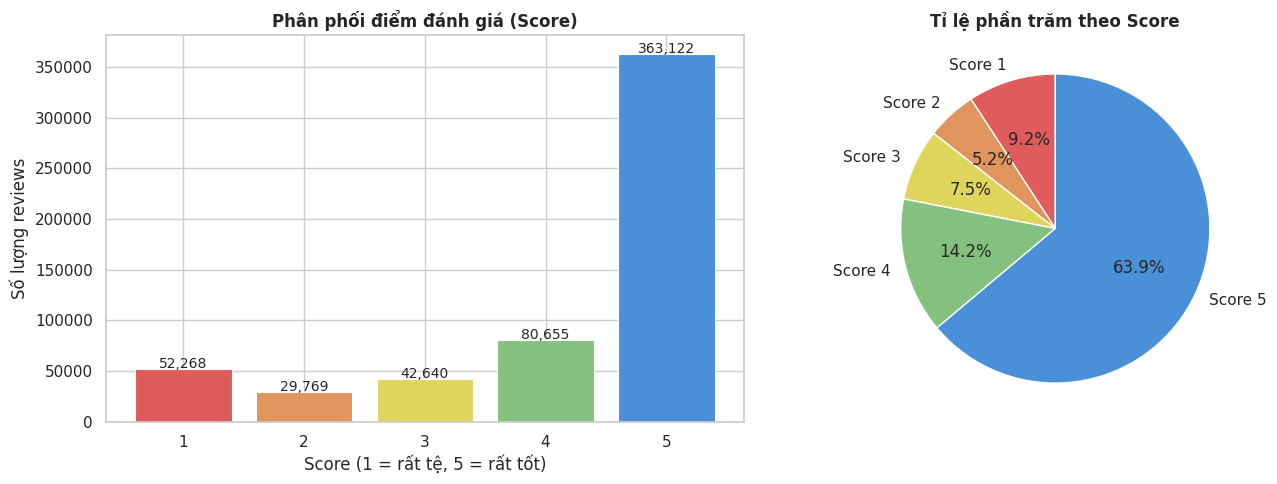

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
score_counts = df['Score'].value_counts().sort_index()
colors = ['#E05C5C', '#E0955C', '#E0D55C', '#85C17E', '#4A90D9']
axes[0].bar(score_counts.index, score_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Phân phối điểm đánh giá (Score)', fontweight='bold')
axes[0].set_xlabel('Score (1 = rất tệ, 5 = rất tốt)')
axes[0].set_ylabel('Số lượng reviews')
for i, (score, count) in enumerate(score_counts.items()):
    axes[0].text(score, count + 500, f'{count:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(score_counts.values, labels=[f'Score {i}' for i in score_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Tỉ lệ phần trăm theo Score', fontweight='bold')

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Binary: 1–2 = Negative, 4–5 = Positive (bỏ Score 3 — neutral)
df_binary = df[df['Score'] != 3].copy()
df_binary['Sentiment'] = df_binary['Score'].apply(
    lambda x: 'positive' if x >= 4 else 'negative'
)

# Ternary: 1–2 = Negative, 3 = Neutral, 4–5 = Positive
df_ternary = df.copy()
df_ternary['Sentiment'] = df_ternary['Score'].apply(
    lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else 'neutral')
)

print("📌 BINARY LABELING (bỏ Score 3):")
print(df_binary['Sentiment'].value_counts())
print(f"Tổng: {len(df_binary):,} mẫu\n")

print("📌 TERNARY LABELING (giữ Score 3 = neutral):")
print(df_ternary['Sentiment'].value_counts())
print(f"Tổng: {len(df_ternary):,} mẫu")

📌 BINARY LABELING (bỏ Score 3):
Sentiment
positive    443777
negative     82037
Name: count, dtype: int64
Tổng: 525,814 mẫu

📌 TERNARY LABELING (giữ Score 3 = neutral):
Sentiment
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64
Tổng: 568,454 mẫu


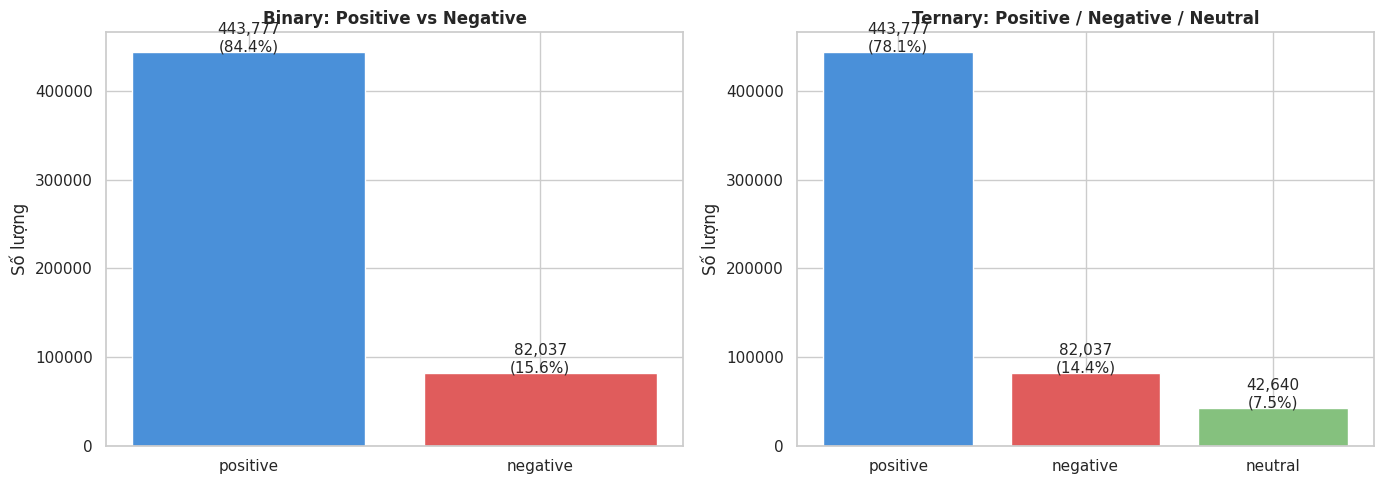

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary
binary_counts = df_binary['Sentiment'].value_counts()
axes[0].bar(binary_counts.index, binary_counts.values,
            color=['#4A90D9', '#E05C5C'], edgecolor='white')
axes[0].set_title('Binary: Positive vs Negative', fontweight='bold')
axes[0].set_ylabel('Số lượng')
for i, (label, count) in enumerate(binary_counts.items()):
    axes[0].text(i, count + 500, f'{count:,}\n({count/len(df_binary)*100:.1f}%)',
                 ha='center', fontsize=11)

# Ternary
ternary_counts = df_ternary['Sentiment'].value_counts()
axes[1].bar(ternary_counts.index, ternary_counts.values,
            color=['#4A90D9', '#E05C5C', '#85C17E'], edgecolor='white')
axes[1].set_title('Ternary: Positive / Negative / Neutral', fontweight='bold')
axes[1].set_ylabel('Số lượng')
for i, (label, count) in enumerate(ternary_counts.items()):
    axes[1].text(i, count + 500, f'{count:,}\n({count/len(df_ternary)*100:.1f}%)',
                 ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
df_binary['text_length']    = df_binary['Text'].astype(str).apply(len)
df_binary['word_count']     = df_binary['Text'].astype(str).apply(lambda x: len(x.split()))
df_binary['summary_length'] = df_binary['Summary'].astype(str).apply(len)

print("📊 Thống kê độ dài văn bản (Text):")
print(df_binary[['text_length', 'word_count']].describe().round(1))

📊 Thống kê độ dài văn bản (Text):
       text_length  word_count
count     525814.0    525814.0
mean         429.4        79.0
std          439.2        78.4
min           12.0         3.0
25%          177.0        33.0
50%          296.0        55.0
75%          517.0        96.0
max        16952.0      2520.0


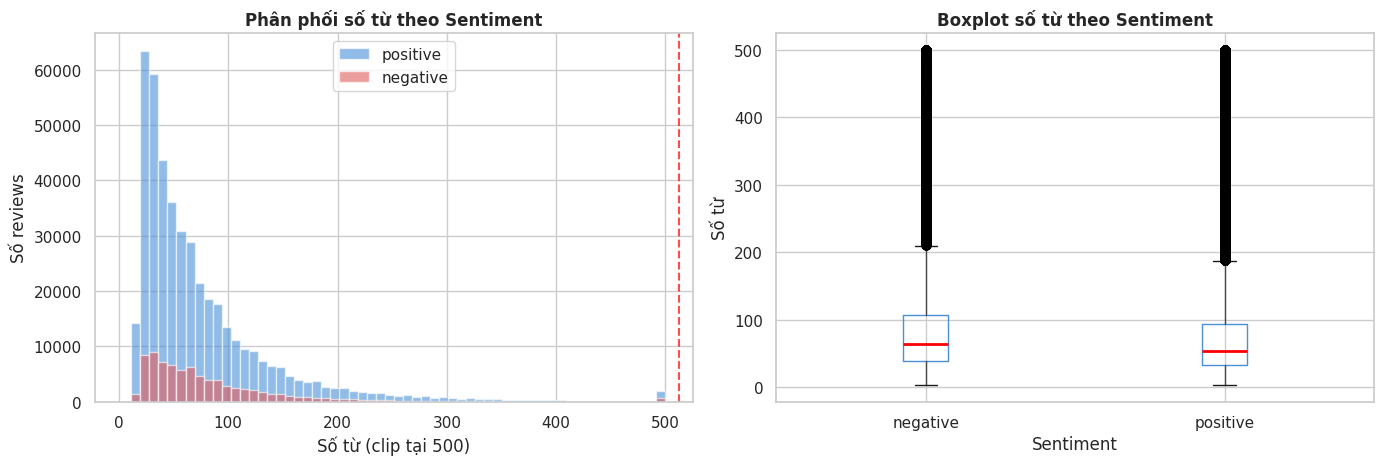


⚠️  Reviews vượt 512 tokens (giới hạn BERT): 2,076 (0.4%)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count theo sentiment
for sentiment, color in zip(['positive', 'negative'], ['#4A90D9', '#E05C5C']):
    subset = df_binary[df_binary['Sentiment'] == sentiment]['word_count']
    axes[0].hist(subset.clip(upper=500), bins=60, alpha=0.6, label=sentiment, color=color)
axes[0].set_title('Phân phối số từ theo Sentiment', fontweight='bold')
axes[0].set_xlabel('Số từ (clip tại 500)')
axes[0].set_ylabel('Số reviews')
axes[0].legend()
axes[0].axvline(x=512, color='red', linestyle='--', alpha=0.7, label='BERT limit (512)')

# Boxplot
df_plot = df_binary[['Sentiment', 'word_count']].copy()
df_plot['word_count'] = df_plot['word_count'].clip(upper=500)
df_plot.boxplot(column='word_count', by='Sentiment', ax=axes[1],
                boxprops=dict(color='#4A90D9'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot số từ theo Sentiment', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Số từ')
plt.suptitle('')

plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Thống kê quan trọng
over_512 = (df_binary['word_count'] > 512).sum()
print(f"\n⚠️  Reviews vượt 512 tokens (giới hạn BERT): {over_512:,} ({over_512/len(df_binary)*100:.1f}%)")

In [11]:
print("=" * 40)
print("KIỂM TRA CHẤT LƯỢNG DATA")
print("=" * 40)
dup_count = df_binary.duplicated(subset=['Text']).sum()
print(f"Số reviews trùng lặp (Text): {dup_count:,}")

null_text = df_binary['Text'].isnull().sum()
null_score = df_binary['Score'].isnull().sum()
print(f"Null trong 'Text'  : {null_text}")
print(f"Null trong 'Score' : {null_score}")

# Xem thử 1 review trùng
if dup_count > 0:
    dup_example = df_binary[df_binary.duplicated(subset=['Text'], keep=False)].head(2)
    print(f"\nVí dụ review trùng:\n{dup_example[['ProductId','Text','Score']].to_string()}")

KIỂM TRA CHẤT LƯỢNG DATA
Số reviews trùng lặp (Text): 161,978
Null trong 'Text'  : 0
Null trong 'Score' : 0

Ví dụ review trùng:
     ProductId                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         Text  Score
3   B000UA0QIQ                                                      

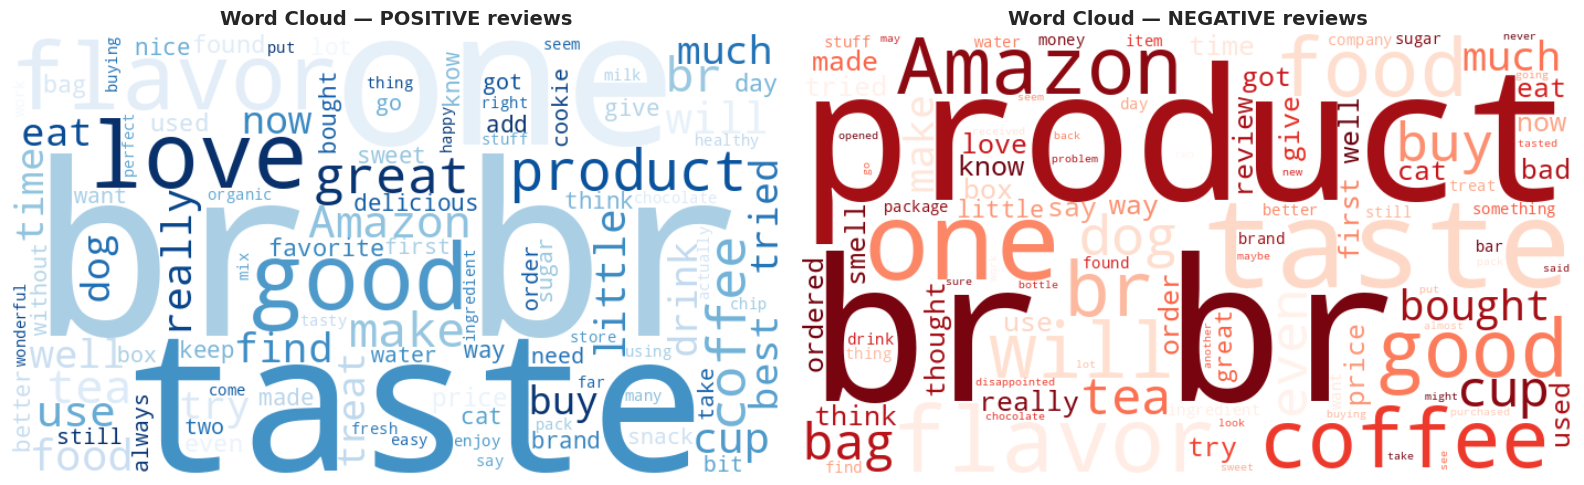

In [12]:
# Gộp text theo sentiment
pos_text = ' '.join(df_binary[df_binary['Sentiment'] == 'positive']['Text'].dropna().sample(5000, random_state=42))
neg_text = ' '.join(df_binary[df_binary['Sentiment'] == 'negative']['Text'].dropna().sample(min(5000, (df_binary['Sentiment']=='negative').sum()), random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=700, height=400, background_color='white',
                   colormap='Blues', max_words=100).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud — POSITIVE reviews', fontweight='bold', fontsize=14)

wc_neg = WordCloud(width=700, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud — NEGATIVE reviews', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

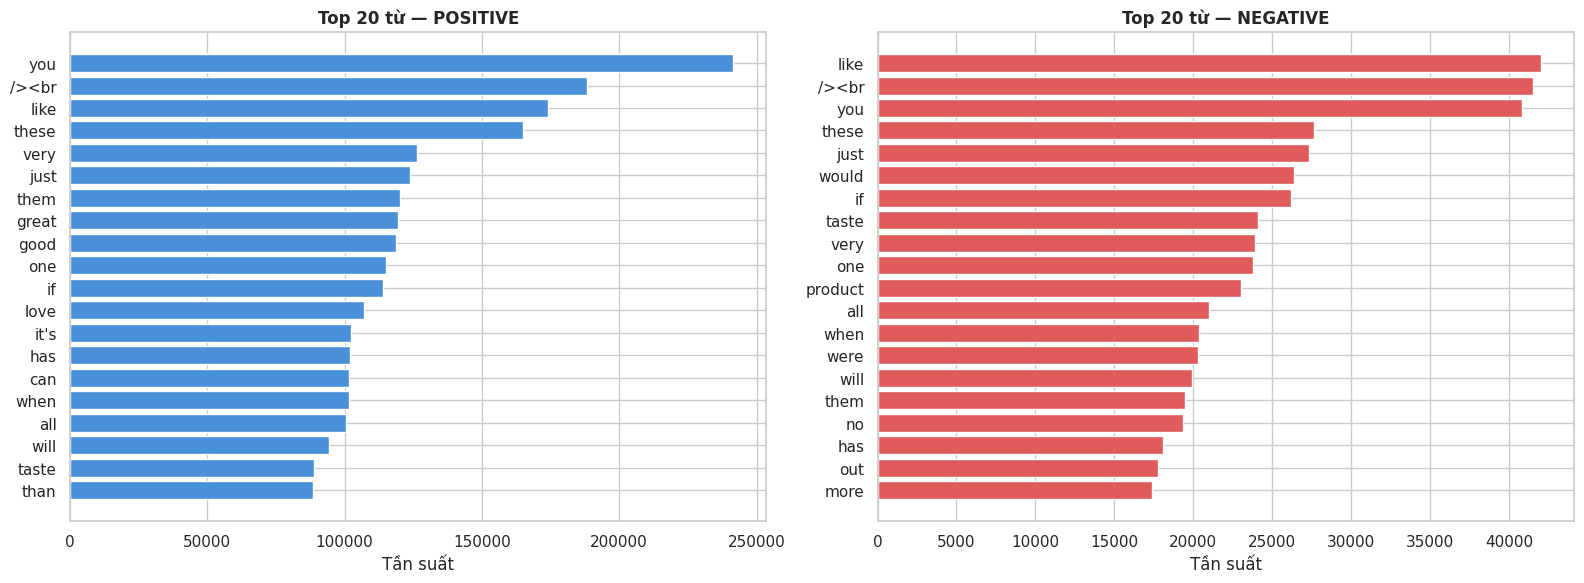

In [13]:
from collections import Counter

def get_top_words(texts, n=20, stopwords=None):
    all_words = []
    for text in texts.dropna():
        words = str(text).lower().split()
        if stopwords:
            words = [w for w in words if w not in stopwords]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

basic_stopwords = {'the','a','an','is','it','this','and','or','of','to','in',
                   'i','was','for','my','have','that','with','on','are','be',
                   'not','but','so','had','as','at','by','from','we','they'}

pos_top = get_top_words(df_binary[df_binary['Sentiment']=='positive']['Text'],
                        stopwords=basic_stopwords)
neg_top = get_top_words(df_binary[df_binary['Sentiment']=='negative']['Text'],
                        stopwords=basic_stopwords)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
words_p, counts_p = zip(*pos_top)
axes[0].barh(list(words_p)[::-1], list(counts_p)[::-1], color='#4A90D9')
axes[0].set_title('Top 20 từ — POSITIVE', fontweight='bold')
axes[0].set_xlabel('Tần suất')

words_n, counts_n = zip(*neg_top)
axes[1].barh(list(words_n)[::-1], list(counts_n)[::-1], color='#E05C5C')
axes[1].set_title('Top 20 từ — NEGATIVE', fontweight='bold')
axes[1].set_xlabel('Tần suất')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

# **Phase 2 - Preprocessing**

In [14]:
!pip install nltk beautifulsoup4 --quiet

import pandas as pd
import numpy as np
import re
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✅ Thư viện sẵn sàng!")

✅ Thư viện sẵn sàng!


In [15]:
print("=" * 50)
print("STEP 1: XÓA DUPLICATE")
print("=" * 50)

before = len(df_binary)
df_clean = df_binary.drop_duplicates(subset=['Text'], keep='first').copy()
after = len(df_clean)

print(f"Trước dedup : {before:,}")
print(f"Sau dedup   : {after:,}")
print(f"Đã xóa      : {before - after:,} dòng ({(before-after)/before*100:.1f}%)")
print(f"\nPhân phối sau dedup:")
print(df_clean['Sentiment'].value_counts())

STEP 1: XÓA DUPLICATE
Trước dedup : 525,814
Sau dedup   : 363,836
Đã xóa      : 161,978 dòng (30.8%)

Phân phối sau dedup:
Sentiment
positive    306766
negative     57070
Name: count, dtype: int64


In [16]:
print("\n" + "=" * 50)
print("STEP 2: BALANCED SAMPLING")
print("=" * 50)

# Lấy số mẫu theo class nhỏ hơn, tối đa 30k mỗi class
n_per_class = min(30000, df_clean['Sentiment'].value_counts().min())

df_pos = df_clean[df_clean['Sentiment'] == 'positive'].sample(n=n_per_class, random_state=42)
df_neg = df_clean[df_clean['Sentiment'] == 'negative'].sample(n=n_per_class, random_state=42)
df_sampled = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Số mẫu mỗi class : {n_per_class:,}")
print(f"Tổng dataset     : {len(df_sampled):,}")
print(f"Positive         : {(df_sampled['Sentiment']=='positive').sum():,}")
print(f"Negative         : {(df_sampled['Sentiment']=='negative').sum():,}")


STEP 2: BALANCED SAMPLING
Số mẫu mỗi class : 30,000
Tổng dataset     : 60,000
Positive         : 30,000
Negative         : 30,000


In [17]:
print("\n" + "=" * 50)
print("STEP 3: ĐỊNH NGHĨA PREPROCESSING PIPELINE")
print("=" * 50)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Thêm custom stopwords cho food reviews
custom_stopwords = {
    'amazon', 'product', 'order', 'buy', 'bought', 'get', 'got',
    'one', 'also', 'would', 'could', 'really', 'very', 'much',
    'even', 'still', 'well', 'like', 'just', 'make', 'use',
    'im', 'ive', 'id', 'its', 'us', 'br'
}
stop_words.update(custom_stopwords)

def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Pipeline tiền xử lý hoàn chỉnh cho 1 review.

    Các bước:
    1. Remove HTML tags (BeautifulSoup)
    2. Lowercase
    3. Expand contractions cơ bản
    4. Remove URLs, emails
    5. Remove số và ký tự đặc biệt
    6. Tokenize
    7. Remove stopwords
    8. Lemmatize
    9. Lọc token quá ngắn
    """
    if pd.isna(text):
        return ""

    # 1. Remove HTML tags
    text = BeautifulSoup(str(text), 'html.parser').get_text()

    # 2. Lowercase
    text = text.lower()

    # 3. Expand contractions phổ biến
    contractions = {
        "won't": "will not", "can't": "cannot", "n't": " not",
        "'re": " are", "'s": " is", "'d": " would",
        "'ll": " will", "'ve": " have", "'m": " am"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)

    # 4. Remove URLs và email
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    # 5. Remove số, ký tự đặc biệt (giữ lại chữ cái và khoảng trắng)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 6. Tokenize
    tokens = text.split()  # Nhanh hơn word_tokenize, đủ dùng

    # 7. Remove stopwords
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words]

    # 8. Lemmatize
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # 9. Lọc token quá ngắn (< 2 ký tự)
    tokens = [t for t in tokens if len(t) >= 2]

    return ' '.join(tokens)

# Test thử
test_review = "I've bought this product from Amazon! It's <br/> AMAZING!! http://example.com Won't buy again... 123"
print("Input  :", test_review)
print("Output :", preprocess_text(test_review))


STEP 3: ĐỊNH NGHĨA PREPROCESSING PIPELINE
Input  : I've bought this product from Amazon! It's <br/> AMAZING!! http://example.com Won't buy again... 123
Output : amazing


In [18]:
print("\nĐang preprocessing... (khoảng 1-2 phút)")

# Dùng tqdm để xem tiến độ
try:
    from tqdm.auto import tqdm
    tqdm.pandas()
    df_sampled['text_clean'] = df_sampled['Text'].progress_apply(preprocess_text)
except:
    df_sampled['text_clean'] = df_sampled['Text'].apply(preprocess_text)

# Xóa dòng text rỗng sau preprocessing
empty_mask = df_sampled['text_clean'].str.strip() == ''
print(f"\nRows trở thành rỗng sau preprocessing: {empty_mask.sum()}")
df_sampled = df_sampled[~empty_mask].reset_index(drop=True)

print(f"✅ Preprocessing xong! {len(df_sampled):,} mẫu sạch")
print("\nVí dụ kết quả:")
for i in [0, 1, 2]:
    row = df_sampled.iloc[i]
    print(f"\n[{row['Sentiment'].upper()}]")
    print(f"  Gốc  : {row['Text'][:120]}...")
    print(f"  Clean: {row['text_clean'][:120]}")


Đang preprocessing... (khoảng 1-2 phút)


  0%|          | 0/60000 [00:00<?, ?it/s]


Rows trở thành rỗng sau preprocessing: 0
✅ Preprocessing xong! 60,000 mẫu sạch

Ví dụ kết quả:

[POSITIVE]
  Gốc  : I bought this and the Torani sugar free brands in the past.  They both have a good taste when I use it in my Ice Coffee....
  Clean: torani sugar free brand past good taste ice coffee davinci brand work good torani brand probably known good price davinc

[NEGATIVE]
  Gốc  : Within 15 minutes, Maggie Mousse, my one-year-old labradoodle, consumed the treat and pulled off chunks of the treat bal...
  Clean: within minute maggie mousse year old labradoodle consumed treat pulled chunk treat ball perhaps young toy blue material 

[NEGATIVE]
  Gốc  : I haven't really had much luck with any lavender extract, including this one.  The smell had such a strong chemical elem...
  Clean: luck lavender extract including smell strong chemical element ever cook want ruin anything spent time making far way kno


In [19]:
df_sampled['clean_word_count'] = df_sampled['text_clean'].apply(lambda x: len(x.split()))

print("\n" + "=" * 50)
print("THỐNG KÊ SAU PREPROCESSING")
print("=" * 50)
print(df_sampled['clean_word_count'].describe().round(1))

# Kiểm tra reviews quá ngắn sau clean
too_short = (df_sampled['clean_word_count'] < 3).sum()
print(f"\nReviews < 3 từ sau clean: {too_short}")


THỐNG KÊ SAU PREPROCESSING
count    60000.0
mean        36.5
std         36.6
min          2.0
25%         15.0
50%         26.0
75%         44.0
max        920.0
Name: clean_word_count, dtype: float64

Reviews < 3 từ sau clean: 3


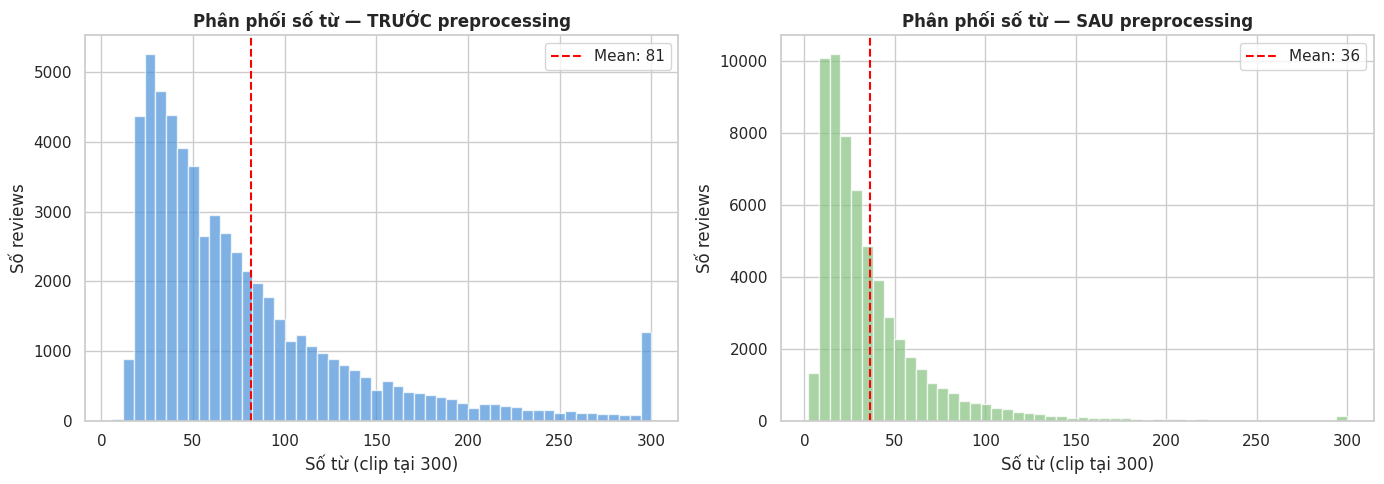

Giảm trung bình số từ: 55.2% sau khi remove stopwords + lemmatize


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trước
df_sampled['original_word_count'] = df_sampled['Text'].apply(lambda x: len(str(x).split()))
axes[0].hist(df_sampled['original_word_count'].clip(upper=300), bins=50,
             color='#4A90D9', alpha=0.7, edgecolor='white')
axes[0].set_title('Phân phối số từ — TRƯỚC preprocessing', fontweight='bold')
axes[0].set_xlabel('Số từ (clip tại 300)')
axes[0].set_ylabel('Số reviews')
axes[0].axvline(x=df_sampled['original_word_count'].mean(), color='red',
                linestyle='--', label=f"Mean: {df_sampled['original_word_count'].mean():.0f}")
axes[0].legend()

# Sau
axes[1].hist(df_sampled['clean_word_count'].clip(upper=300), bins=50,
             color='#85C17E', alpha=0.7, edgecolor='white')
axes[1].set_title('Phân phối số từ — SAU preprocessing', fontweight='bold')
axes[1].set_xlabel('Số từ (clip tại 300)')
axes[1].set_ylabel('Số reviews')
axes[1].axvline(x=df_sampled['clean_word_count'].mean(), color='red',
                linestyle='--', label=f"Mean: {df_sampled['clean_word_count'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

reduction = (1 - df_sampled['clean_word_count'].mean() / df_sampled['original_word_count'].mean()) * 100
print(f"Giảm trung bình số từ: {reduction:.1f}% sau khi remove stopwords + lemmatize")

In [21]:
# BERT KHÔNG cần remove stopwords vì nó hiểu context!
# → Chỉ clean HTML và ký tự đặc biệt

def preprocess_for_bert(text):
    """
    Preprocessing nhẹ cho BERT:
    - Chỉ clean HTML, URLs, ký tự đặc biệt
    - GIỮ stopwords và không lemmatize
    - Truncate ở 512 từ (BERT limit)
    """
    if pd.isna(text):
        return ""

    # Remove HTML
    text = BeautifulSoup(str(text), 'html.parser').get_text()

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove ký tự đặc biệt (nhẹ hơn)
    text = re.sub(r'[^a-z0-9\s\.,!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Truncate tại 512 từ
    words = text.split()
    if len(words) > 512:
        text = ' '.join(words[:512])

    return text

df_sampled['text_for_bert'] = df_sampled['Text'].apply(preprocess_for_bert)

print("✅ Đã tạo cột 'text_for_bert' (preprocessing nhẹ, giữ stopwords)")
print("\nVí dụ text_for_bert:")
print(df_sampled['text_for_bert'].iloc[0][:200])

✅ Đã tạo cột 'text_for_bert' (preprocessing nhẹ, giữ stopwords)

Ví dụ text_for_bert:
i bought this and the torani sugar free brands in the past. they both have a good taste when i use it in my ice coffee. the davinci brand works just as good as the torani brand which is probably more 


In [22]:
from sklearn.model_selection import train_test_split

print("\n" + "=" * 50)
print("TRAIN / VAL / TEST SPLIT")
print("=" * 50)

X = df_sampled['text_clean']           # Cho ML models + LSTM
X_bert = df_sampled['text_for_bert']   # Cho BERT
df_sampled['label'] = df_sampled['Sentiment'].map({'negative': 0, 'positive': 1}) # Create numerical labels
y = df_sampled['label']

# Chia 70 / 10 / 20 — stratified để giữ tỉ lệ class
X_temp, X_test, X_bert_temp, X_bert_test, y_temp, y_test = train_test_split(
    X, X_bert, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, X_bert_train, X_bert_val, y_train, y_val = train_test_split(
    X_temp, X_bert_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)
# 0.125 × 0.80 = 0.10 → Val = 10% tổng

print(f"Train : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Val   : {len(X_val):,} ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test  : {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nKiểm tra stratified — Tỉ lệ positive:")
print(f"  Train: {y_train.mean():.3f}")
print(f"  Val  : {y_val.mean():.3f}")
print(f"  Test : {y_test.mean():.3f}")


TRAIN / VAL / TEST SPLIT
Train : 42,000 (70%)
Val   : 6,000 (10%)
Test  : 12,000 (20%)

Kiểm tra stratified — Tỉ lệ positive:
  Train: 0.500
  Val  : 0.500
  Test : 0.500


In [23]:
import pickle

# Lưu splits dạng dict để dùng ở Phase 3, 4, 5
data_splits = {
    'X_train': X_train.reset_index(drop=True),
    'X_val':   X_val.reset_index(drop=True),
    'X_test':  X_test.reset_index(drop=True),
    'X_bert_train': X_bert_train.reset_index(drop=True),
    'X_bert_val':   X_bert_val.reset_index(drop=True),
    'X_bert_test':  X_bert_test.reset_index(drop=True),
    'y_train': y_train.reset_index(drop=True),
    'y_val':   y_val.reset_index(drop=True),
    'y_test':  y_test.reset_index(drop=True),
}

with open('data_splits.pkl', 'wb') as f:
    pickle.dump(data_splits, f)

# Lưu lên Drive
!cp data_splits.pkl /content/drive/MyDrive/data_splits.pkl
!cp data_splits.pkl /content/drive/MyDrive/df_processed.pkl  # backup

# Cũng lưu CSV để dễ kiểm tra
df_sampled[['Text', 'text_clean', 'text_for_bert', 'Score', 'Sentiment', 'label']].to_csv(
    'df_processed.csv', index=False
)
!cp df_processed.csv /content/drive/MyDrive/df_processed.csv

print("\n✅ Đã lưu:")
print("   - data_splits.pkl  → dùng cho Phase 3-5")
print("   - df_processed.csv → xem trực quan")


✅ Đã lưu:
   - data_splits.pkl  → dùng cho Phase 3-5
   - df_processed.csv → xem trực quan


# **PHASE 3 + 4 + 5 — FEATURE ENGINEERING + MODEL TRAINING**

In [24]:
import pickle, os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, roc_auc_score,
                              RocCurveDisplay)
from sklearn.model_selection import cross_val_score

print("✅ Thư viện sẵn sàng!")

✅ Thư viện sẵn sàng!


In [25]:
with open('/content/drive/MyDrive/data_splits.pkl', 'rb') as f:
    splits = pickle.load(f)

X_train      = splits['X_train']
X_val        = splits['X_val']
X_test       = splits['X_test']
X_bert_train = splits['X_bert_train']
X_bert_val   = splits['X_bert_val']
X_bert_test  = splits['X_bert_test']
y_train      = splits['y_train']
y_val        = splits['y_val']
y_test       = splits['y_test']

# Gộp train+val cho ML models (sklearn tự CV)
X_trainval = pd.concat([X_train, X_val]).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val]).reset_index(drop=True)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print("✅ Data loaded!")

Train: 42,000 | Val: 6,000 | Test: 12,000
✅ Data loaded!


In [26]:
results_log = {}   # Lưu kết quả tất cả models để so sánh cuối

def evaluate_model(name, y_true, y_pred, y_prob=None):
    """In metrics + lưu vào results_log."""
    acc  = accuracy_score(y_true, y_pred)
    f1_w = f1_score(y_true, y_pred, average='weighted')
    f1_m = f1_score(y_true, y_pred, average='macro')
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else None

    results_log[name] = {
        'Accuracy':  round(acc,  4),
        'F1 weighted': round(f1_w, 4),
        'F1 macro':    round(f1_m, 4),
        'ROC-AUC':   round(auc, 4) if auc else '-',
    }
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  F1 weighted : {f1_w:.4f}")
    print(f"  F1 macro    : {f1_m:.4f}")
    if auc:
        print(f"  ROC-AUC     : {auc:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=['negative','positive']))
    return acc, f1_w

def plot_confusion_matrix(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'], ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

## **MODEL 1 — NAIVE BAYES**


🔵 MODEL 1: NAIVE BAYES (Complement NB)
Feature: TF-IDF unigram + bigram, max_features=50k
  Training time: 16.6s

  Naive Bayes
  Accuracy    : 0.8732
  F1 weighted : 0.8732
  F1 macro    : 0.8732
  ROC-AUC     : 0.9436

  Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.88      0.87      6000
    positive       0.88      0.87      0.87      6000

    accuracy                           0.87     12000
   macro avg       0.87      0.87      0.87     12000
weighted avg       0.87      0.87      0.87     12000



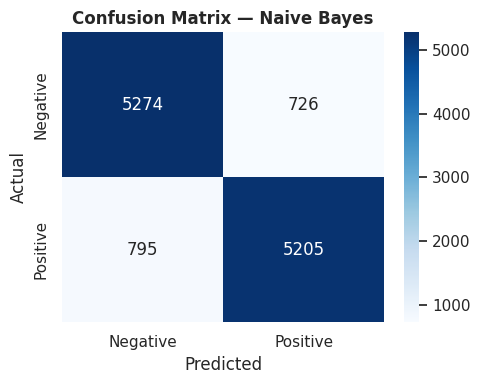

In [27]:
print("\n🔵 MODEL 1: NAIVE BAYES (Complement NB)")
print("Feature: TF-IDF unigram + bigram, max_features=50k")

t0 = time.time()
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50000,
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', ComplementNB(alpha=0.1))
    # ComplementNB tốt hơn MultinomialNB cho imbalanced (dù đã balance)
])

nb_pipeline.fit(X_trainval, y_trainval)
nb_pred  = nb_pipeline.predict(X_test)
nb_prob  = nb_pipeline.predict_proba(X_test)[:, 1]
print(f"  Training time: {time.time()-t0:.1f}s")

evaluate_model("Naive Bayes", y_test, nb_pred, nb_prob)
plot_confusion_matrix("Naive Bayes", y_test, nb_pred)

## **MODEL 2 — LOGISTIC REGRESSION**


🟢 MODEL 2: LOGISTIC REGRESSION
Feature: TF-IDF unigram + bigram, max_features=80k
  Training time: 9.3s

  Logistic Regression
  Accuracy    : 0.8846
  F1 weighted : 0.8846
  F1 macro    : 0.8846
  ROC-AUC     : 0.9525

  Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.90      0.89      6000
    positive       0.89      0.87      0.88      6000

    accuracy                           0.88     12000
   macro avg       0.88      0.88      0.88     12000
weighted avg       0.88      0.88      0.88     12000



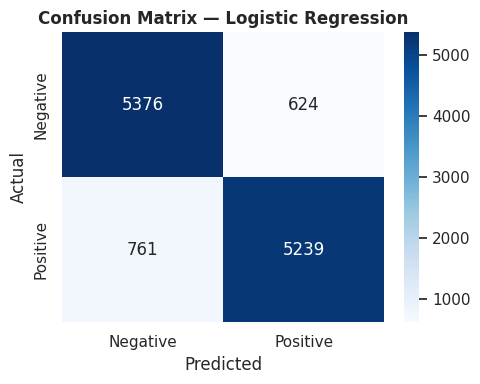


Top 15 features → POSITIVE:
['great', 'best', 'delicious', 'love', 'perfect', 'excellent', 'favorite', 'nice', 'wonderful', 'good', 'easy', 'highly', 'amazing', 'yummy', 'highly recommend']

Top 15 features → NEGATIVE:
['disappointed', 'worst', 'terrible', 'disappointing', 'awful', 'unfortunately', 'stale', 'horrible', 'thought', 'disappointment', 'hoping', 'waste', 'bland', 'sorry', 'return']


In [28]:
print("\n🟢 MODEL 2: LOGISTIC REGRESSION")
print("Feature: TF-IDF unigram + bigram, max_features=80k")

t0 = time.time()
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=80000,
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver='lbfgs',
        class_weight='balanced',
        random_state=42
    ))
])

lr_pipeline.fit(X_trainval, y_trainval)
lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]
print(f"  Training time: {time.time()-t0:.1f}s")

evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
plot_confusion_matrix("Logistic Regression", y_test, lr_pred)

# Top features (gây ấn tượng khi trình bày)
tfidf_feat  = lr_pipeline['tfidf'].get_feature_names_out()
lr_coef     = lr_pipeline['clf'].coef_[0]
top_pos_idx = np.argsort(lr_coef)[-15:][::-1]
top_neg_idx = np.argsort(lr_coef)[:15]

print("\nTop 15 features → POSITIVE:")
print([tfidf_feat[i] for i in top_pos_idx])
print("\nTop 15 features → NEGATIVE:")
print([tfidf_feat[i] for i in top_neg_idx])

## **MODEL 3 — LINEAR SVM**


🟠 MODEL 3: LINEAR SVM
Feature: TF-IDF unigram + bigram, max_features=80k
  Training time: 7.9s

  SVM (LinearSVC)
  Accuracy    : 0.8891
  F1 weighted : 0.8891
  F1 macro    : 0.8891
  ROC-AUC     : 0.9556

  Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.89      0.89      6000
    positive       0.89      0.88      0.89      6000

    accuracy                           0.89     12000
   macro avg       0.89      0.89      0.89     12000
weighted avg       0.89      0.89      0.89     12000



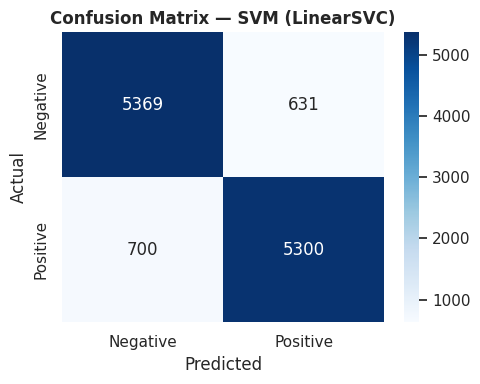

In [29]:
print("\n🟠 MODEL 3: LINEAR SVM")
print("Feature: TF-IDF unigram + bigram, max_features=80k")

t0 = time.time()
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=80000,
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', LinearSVC(
        C=0.5,
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

svm_pipeline.fit(X_trainval, y_trainval)
svm_pred = svm_pipeline.predict(X_test)

# LinearSVC không có predict_proba → dùng decision_function cho AUC
svm_score = svm_pipeline.decision_function(X_test)
print(f"  Training time: {time.time()-t0:.1f}s")

evaluate_model("SVM (LinearSVC)", y_test, svm_pred, svm_score)
plot_confusion_matrix("SVM (LinearSVC)", y_test, svm_pred)

## **MODEL 4 — BiLSTM**

In [30]:
print("\n🟣 MODEL 4: BiLSTM")

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM,
                                      GlobalMaxPooling1D, Dense, Dropout,
                                      SpatialDropout1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Hyperparameters
MAX_VOCAB  = 30000
MAX_LEN    = 150    # Cắt ở 150 từ sau khi đã clean (median=26, 90th ~85)
EMBED_DIM  = 128
LSTM_UNITS = 64
BATCH_SIZE = 256
EPOCHS     = 10

# Tokenize
tokenizer_lstm = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_train),
                              maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq   = pad_sequences(tokenizer_lstm.texts_to_sequences(X_val),
                              maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer_lstm.texts_to_sequences(X_test),
                              maxlen=MAX_LEN, padding='post', truncating='post')

print(f"  Vocab size   : {len(tokenizer_lstm.word_index):,}")
print(f"  Sequence len : {MAX_LEN}")
print(f"  Train shape  : {X_train_seq.shape}")


🟣 MODEL 4: BiLSTM
  Vocab size   : 37,357
  Sequence len : 150
  Train shape  : (42000, 150)


In [31]:
def build_bilstm():
    model = Sequential([
        Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(LSTM_UNITS, return_sequences=True, dropout=0.2)),
        Bidirectional(LSTM(LSTM_UNITS // 2, dropout=0.2)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_bilstm()
lstm_model.summary()

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-5, verbose=1)
]

t0 = time.time()
history = lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
print(f"\n  Training time: {time.time()-t0:.1f}s")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 26s 96ms/step - accuracy: 0.7963 - loss: 0.4271 - val_accuracy: 0.8642 - val_loss: 0.3271 - learning_rate: 0.0010
Epoch 2/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.8985 - loss: 0.2614 - val_accuracy: 0.8643 - val_loss: 0.3257 - learning_rate: 0.0010
Epoch 3/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9232 - loss: 0.2058 - val_accuracy: 0.8572 - val_loss: 0.3491 - learning_rate: 0.0010
Epoch 4/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9450 - loss: 0.1574
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9400 - loss: 0.1665 - val_accuracy: 0.8517 - val_loss: 0.3759 - learning_rate: 0.0010
Epoch 5/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.9578 - loss: 0.1231 - val_accuracy: 0.8573 - val_loss: 0.4536 - learning_rate: 5.0000e-04

  Training time: 63.5s


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step

  BiLSTM
  Accuracy    : 0.8712
  F1 weighted : 0.8711
  F1 macro    : 0.8711
  ROC-AUC     : 0.9437

  Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.85      0.87      6000
    positive       0.86      0.89      0.87      6000

    accuracy                           0.87     12000
   macro avg       0.87      0.87      0.87     12000
weighted avg       0.87      0.87      0.87     12000



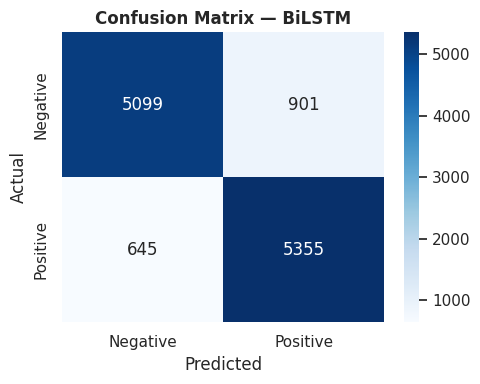

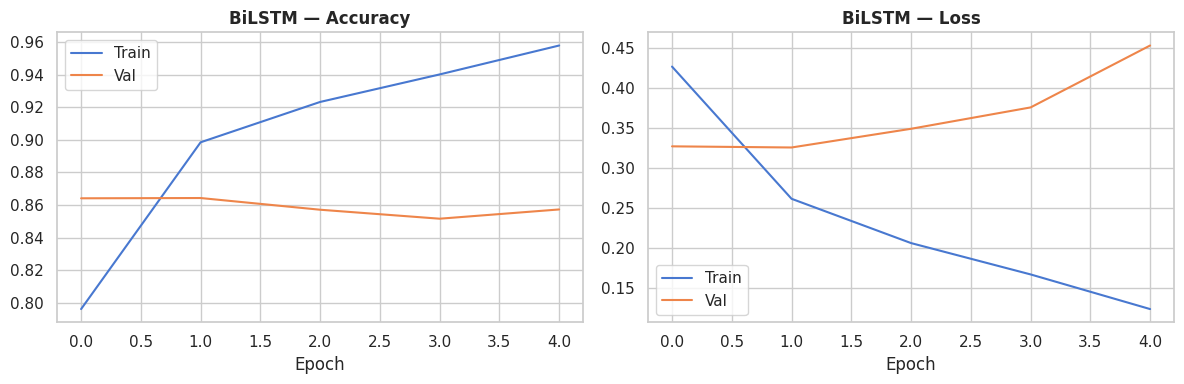

In [32]:
lstm_prob = lstm_model.predict(X_test_seq, batch_size=512).flatten()
lstm_pred = (lstm_prob >= 0.5).astype(int)

evaluate_model("BiLSTM", y_test, lstm_pred, lstm_prob)
plot_confusion_matrix("BiLSTM", y_test, lstm_pred)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('BiLSTM — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('BiLSTM — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('bilstm_history.png', dpi=120, bbox_inches='tight')
plt.show()

## **MODEL 5 — DistilBERT**

In [33]:
print("\n🔴 MODEL 5: DistilBERT fine-tuning")
print("  Model: distilbert-base-uncased")
print("  Dùng text_for_bert (giữ stopwords, nhẹ clean)")

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (DistilBertTokenizerFast,
                           DistilBertForSequenceClassification,
                           get_linear_schedule_with_warmup)
from torch.optim import AdamW

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BERT_MODEL = 'distilbert-base-uncased'
MAX_LEN_BERT = 256   # 256 đủ, nhanh hơn 512 trên Colab
BERT_BATCH   = 32
BERT_EPOCHS  = 3
BERT_LR      = 2e-5

print(f"  Device: {DEVICE}")

tokenizer_bert = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)


🔴 MODEL 5: DistilBERT fine-tuning
  Model: distilbert-base-uncased
  Dùng text_for_bert (giữ stopwords, nhẹ clean)
  Device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [34]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

print("  Tokenizing... (khoảng 1-2 phút)")
train_dataset = SentimentDataset(X_bert_train, y_train, tokenizer_bert, MAX_LEN_BERT)
val_dataset   = SentimentDataset(X_bert_val,   y_val,   tokenizer_bert, MAX_LEN_BERT)
test_dataset  = SentimentDataset(X_bert_test,  y_test,  tokenizer_bert, MAX_LEN_BERT)

train_loader = DataLoader(train_dataset, batch_size=BERT_BATCH, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BERT_BATCH*2)
test_loader  = DataLoader(test_dataset,  batch_size=BERT_BATCH*2)
print("  Tokenizing xong!")

  Tokenizing... (khoảng 1-2 phút)
  Tokenizing xong!


In [35]:
import torch
import pickle
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BERT_MODEL = "distilbert-base-uncased"
MAX_LEN = 256
BATCH_SIZE = 32
EPOCHS = 3
LR = 2e-5

print("Device:", DEVICE)

# load splits
with open('/content/drive/MyDrive/data_splits.pkl', 'rb') as f:
    splits = pickle.load(f)

X_train = splits['X_bert_train']
X_val   = splits['X_bert_val']
X_test  = splits['X_bert_test']

y_train = splits['y_train']
y_val   = splits['y_val']
y_test  = splits['y_test']

tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)

# Dataset
class SentimentDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item


train_dataset = SentimentDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = SentimentDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset  = SentimentDataset(X_test, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE
)

# model
model = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL,
    num_labels=2
)

model = model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

def train_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:

        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        outputs = model(**batch)

        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        preds = outputs.logits.argmax(dim=-1)

        correct += (preds == batch["labels"]).sum().item()

        total += batch["labels"].size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for batch in loader:

            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            outputs = model(**batch)

            loss = outputs.loss

            total_loss += loss.item()

            preds = outputs.logits.argmax(dim=-1)

            correct += (preds == batch["labels"]).sum().item()

            total += batch["labels"].size(0)

    return total_loss / len(loader), correct / total


print("\nTraining DistilBERT...\n")

best_val = 0
t0 = time.time()

for epoch in range(EPOCHS):

    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, val_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"Val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), "best_bert.pt")

model.load_state_dict(torch.load("best_bert.pt"))

print("\nTraining time:", (time.time()-t0)/60, "minutes")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Training DistilBERT — 3 epochs...
  Epoch 1/3 | Train loss: 0.2452 acc: 0.8991 | Val loss: 0.1558 acc: 0.9373
  Epoch 2/3 | Train loss: 0.1197 acc: 0.9600 | Val loss: 0.1550 acc: 0.9460
  Epoch 3/3 | Train loss: 0.0714 acc: 0.9790 | Val loss: 0.1922 acc: 0.9465

  Training time: 46.2 phút



  DistilBERT
  Accuracy    : 0.9463
  F1 weighted : 0.9462
  F1 macro    : 0.9462
  ROC-AUC     : 0.9868

  Classification Report:
              precision    recall  f1-score   support

    negative       0.94      0.95      0.95      6000
    positive       0.95      0.94      0.95      6000

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



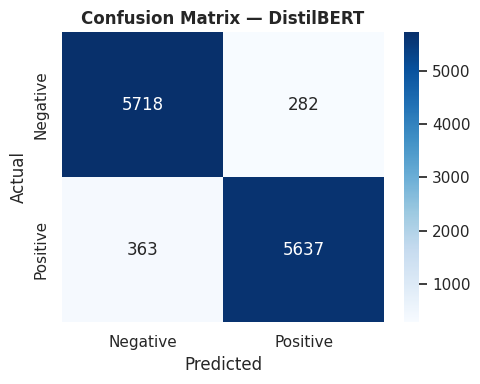

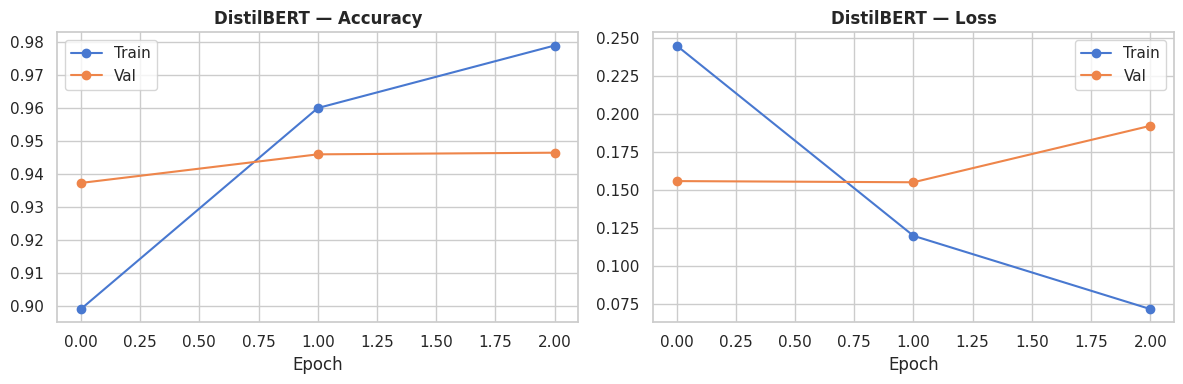

In [36]:
_, _, bert_prob = eval_epoch(bert_model, test_loader)
bert_prob  = np.array(bert_prob)
bert_pred  = (bert_prob >= 0.5).astype(int)

evaluate_model("DistilBERT", y_test, bert_pred, bert_prob)
plot_confusion_matrix("DistilBERT", y_test, bert_pred)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(bert_history['train_acc'], 'o-', label='Train')
axes[0].plot(bert_history['val_acc'],   'o-', label='Val')
axes[0].set_title('DistilBERT — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(bert_history['train_loss'], 'o-', label='Train')
axes[1].plot(bert_history['val_loss'],   'o-', label='Val')
axes[1].set_title('DistilBERT — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('bert_history.png', dpi=120, bbox_inches='tight')
plt.show()

# **Phase 6 - EVALUATION & COMPARISON TABLE**


BẢNG SO SÁNH TẤT CẢ MODELS
                     Accuracy  F1 weighted  F1 macro  ROC-AUC
Model                                                        
DistilBERT             0.9463       0.9462    0.9462   0.9868
SVM (LinearSVC)        0.8891       0.8891    0.8891   0.9556
Logistic Regression    0.8846       0.8846    0.8846   0.9525
Naive Bayes            0.8732       0.8732    0.8732   0.9436
BiLSTM                 0.8712       0.8711    0.8711   0.9437


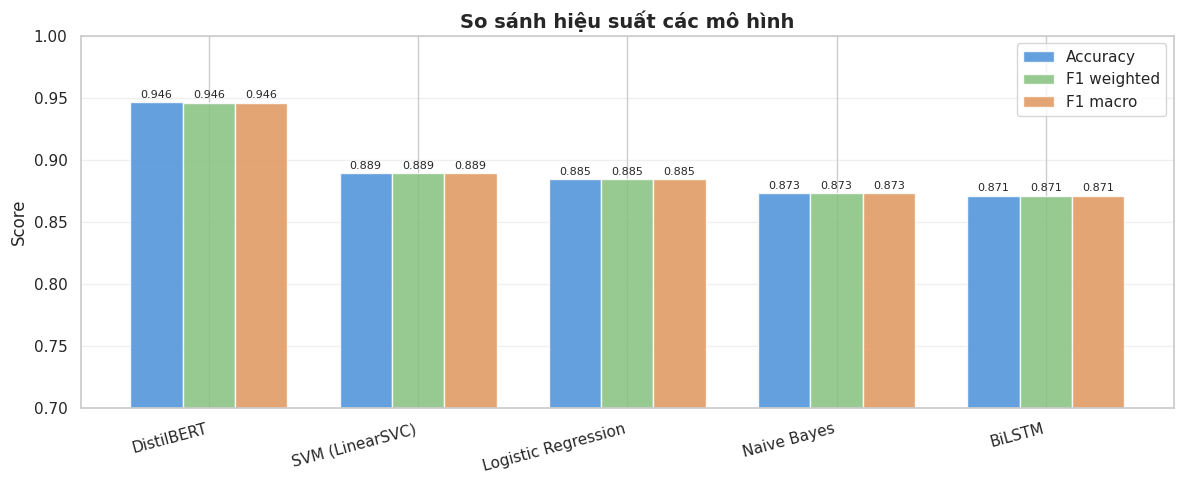

In [37]:
print("\n" + "="*60)
print("BẢNG SO SÁNH TẤT CẢ MODELS")
print("="*60)

df_results = pd.DataFrame(results_log).T
df_results.index.name = 'Model'
df_results = df_results.sort_values('F1 weighted', ascending=False)
print(df_results.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
metrics = ['Accuracy', 'F1 weighted', 'F1 macro']
x = np.arange(len(df_results))
width = 0.25
colors = ['#4A90D9', '#85C17E', '#E0955C']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = df_results[metric].astype(float)
    bars = ax.bar(x + i*width, vals, width, label=metric, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(df_results.index, rotation=15, ha='right')
ax.set_ylim(0.7, 1.0)
ax.set_title('So sánh hiệu suất các mô hình', fontweight='bold', fontsize=14)
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

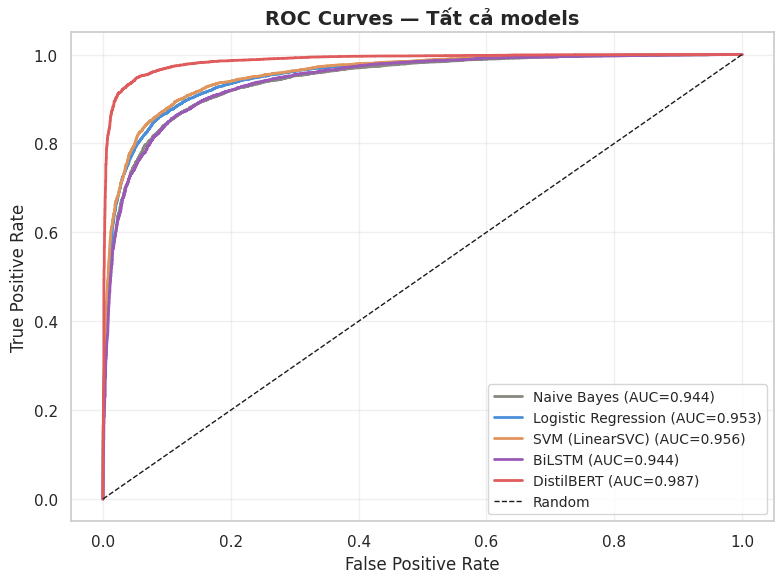

In [38]:
from sklearn.metrics import roc_curve, auc as calc_auc

fig, ax = plt.subplots(figsize=(8, 6))

model_probs = {
    'Naive Bayes':          nb_prob,
    'Logistic Regression':  lr_prob,
    'SVM (LinearSVC)':      svm_score,
    'BiLSTM':               lstm_prob,
    'DistilBERT':           bert_prob,
}
line_colors = ['#888780', '#4A90D9', '#E0955C', '#9B59B6', '#E05C5C']

for (name, prob), color in zip(model_probs.items(), line_colors):
    # Normalize scores về [0,1] cho SVM
    prob_norm = (prob - prob.min()) / (prob.max() - prob.min() + 1e-9)
    fpr, tpr, _ = roc_curve(y_test, prob_norm)
    auc_val = calc_auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Tất cả models', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Lấy best model (thường là DistilBERT)
print("\n📊 ERROR ANALYSIS — DistilBERT")
print("Phân tích những review bị dự đoán SAI\n")

# Load lại test texts gốc
df_processed = pd.read_csv('/content/drive/MyDrive/df_processed.csv')

# Map lại test indices
test_idx = X_bert_test.index if hasattr(X_bert_test, 'index') else range(len(X_bert_test))

errors_df = pd.DataFrame({
    'text':       list(X_bert_test),
    'true_label': list(y_test),
    'pred_label': bert_pred,
    'confidence': bert_prob,
})
errors_df['correct'] = errors_df['true_label'] == errors_df['pred_label']

# False Positive: predict Positive nhưng thực ra Negative
fp = errors_df[(errors_df['true_label']==0) & (errors_df['pred_label']==1)]
# False Negative: predict Negative nhưng thực ra Positive
fn = errors_df[(errors_df['true_label']==1) & (errors_df['pred_label']==0)]

print(f"False Positives (pred=POS, actual=NEG): {len(fp)}")
print(f"False Negatives (pred=NEG, actual=POS): {len(fn)}")

print("\n--- 3 ví dụ False Positive (model nhầm NEG thành POS) ---")
for _, row in fp.nlargest(3, 'confidence').iterrows():
    print(f"  Text: {row['text'][:120]}...")
    print(f"  Confidence: {row['confidence']:.3f}\n")

print("--- 3 ví dụ False Negative (model nhầm POS thành NEG) ---")
for _, row in fn.nsmallest(3, 'confidence').iterrows():
    print(f"  Text: {row['text'][:120]}...")
    print(f"  Confidence: {row['confidence']:.3f}\n")


📊 ERROR ANALYSIS — DistilBERT
Phân tích những review bị dự đoán SAI

False Positives (pred=POS, actual=NEG): 282
False Negatives (pred=NEG, actual=POS): 363

--- 3 ví dụ False Positive (model nhầm NEG thành POS) ---
  Text: as i stated above, this is a great product for cats. my four cats, some old some young, love it. especially my 5 years o...
  Confidence: 0.999

  Text: chip davis has created a wonderful hot chocolate drink and i have purchaseda number of cans as christmas gifts for famil...
  Confidence: 0.999

  Text: i put this on everything i eat, i use a 17 oz bottle about every 2 months, it is amazing on ramen, pizza, burritos, chip...
  Confidence: 0.999

--- 3 ví dụ False Negative (model nhầm POS thành NEG) ---
  Text: i like ginger beer but was disappointed in this ginger ale. it is not ginger beer and is especially not fiery. then most...
  Confidence: 0.001

  Text: the taste of the onions in this first jar is not up to the standards i ve come to expect with my many jar